# Fraud Detection System (End-to-End Machine Learning Project)

## 📌 Project Overview

This project aims to build an end-to-end machine learning system for detecting fraudulent credit card transactions. The dataset is highly imbalanced and represents real-world challenges in fraud detection systems used in financial institutions.

The goal is not only to build a predictive model but to design a complete ML pipeline including data preprocessing, feature engineering, model evaluation, explainability, API deployment, and monitoring.

---

## 🎯 Objectives

- Detect fraudulent transactions with high recall
- Handle extreme class imbalance
- Build interpretable and production-ready ML models
- Deploy model via REST API
- Implement basic monitoring for data and prediction drift

---

## 📊 Dataset

The dataset used is the **Credit Card Fraud Detection Dataset**, which contains:

- 284,807 transactions
- 31 features
- Highly imbalanced target variable

### Features:
- `V1` to `V28`: PCA-transformed anonymized features
- `Time`: seconds elapsed between transactions
- `Amount`: transaction amount
- `Class`: target variable (0 = normal, 1 = fraud)

---

## 🧠 Problem Type

- Supervised Learning
- Binary Classification
- Highly Imbalanced Dataset

---

## ⚙️ Planned Workflow

1. Data Exploration (EDA)
2. Data Preprocessing
3. Feature Engineering
4. Model Training:
   - Logistic Regression (Baseline)
   - Random Forest
   - XGBoost
   - LightGBM (Final Model)
   - Neural Network (MLP for comparison)
5. Model Evaluation (Precision, Recall, PR-AUC)
6. Model Explainability (SHAP)
7. API Development (FastAPI)
8. Monitoring (Data + Prediction Drift)

---

## 🧪 Evaluation Metrics

Due to class imbalance, the following metrics are used:

- Precision
- Recall
- F1-score
- PR-AUC (Primary Metric)
- ROC-AUC

---

## 🚀 Tech Stack

- Python
- Pandas, NumPy
- Scikit-learn
- XGBoost / LightGBM / CatBoost
- SHAP
- FastAPI
- Evidently AI (Monitoring)

---

## 📌 Key Focus Areas

- Handling imbalanced data
- Feature engineering for transactional behavior
- Model interpretability
- End-to-end ML pipeline design

---

## 📈 Future Improvements

- Real-time streaming fraud detection
- Advanced deep learning models (LSTM/Transformer)
- Production-grade deployment with Docker & CI/CD

# 📦 Environment Setup & Library Imports

This notebook follows a modular ML workflow.  
All required dependencies are imported at the beginning to ensure reproducibility and clarity.

We follow a production-style structure:
- Data handling (Pandas, NumPy)
- Visualization (Matplotlib, Seaborn)
- Modeling (Scikit-learn, XGBoost, LightGBM)
- Imbalanced learning (SMOTE)
- Model explainability (SHAP)

This setup simulates a real-world machine learning pipeline environment.

In [1]:
# Core libraries
import numpy as np
import pandas as pd


# Visualization
import seaborn as sns
import matplotlib.pyplot as plt


# Preprocessing & ML
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Imbalanced learning (if needed later)
from imblearn.over_sampling import SMOTE

# Gradient boosting models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Neural Network model
from sklearn.neural_network import MLPClassifier

# Explainability
import shap


In [2]:
# -----------------------------
# Global Style Configuration
# -----------------------------
sns.set_theme(
    style= "whitegrid",
    context= "notebook",
    font= "Times New Roman",
    font_scale= 1.1
)

plt.rcParams.update({
    "figure.figsize": (7, 4),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
    "legend.fontsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

# -----------------------------
# Advanced Smart Annotation
# -----------------------------
def annotate_smart(ax_or_g, min_height_ratio= 0.07):
    """
    Advanced smart annotation for bar-based plots.
    - Handles small bars automatically
    - Works with FacetGrid or single axis
    - Supports counts and percentages
    - Adjusts text contrast dynamically
    """

    if isinstance(ax_or_g, sns.axisgrid.FacetGrid):
        axes = ax_or_g.axes.flat
    else:
        axes = [ax_or_g]

    for ax in axes:
        ymax = ax.get_ylim()[1]

        for container in ax.containers:
            for patch in container:
                height = patch.get_height()
                if height <= 0:
                    continue

                x = patch.get_x() + patch.get_width() / 2

                # Determine placement
                if height < ymax * min_height_ratio:
                    y = height + ymax * 0.02
                    va = "bottom"
                    inside = False
                else:
                    y = height / 2
                    va = "center"
                    inside = True

                # Dynamic text formatting
                if height < 10:
                    label = f"{height:.1f}"
                else:
                    label = f"{int(height)}"

                # Dynamic contrast
                facecolor = patch.get_facecolor()
                brightness = (0.299 * facecolor[0] + 
                              0.587 * facecolor[1] + 
                              0.114 * facecolor[2])

                if inside:
                    color = "white" if brightness < 0.5 else "black"
                else:
                    color = "black"

                ax.text(
                    x, y, label,
                    ha= "center",
                    va= va,
                    fontsize= 9,
                    fontweight= "bold",
                    color= "black"
                    # color= color
                )

        ax.grid(False)


In [3]:
df = pd.read_csv("creditcard.csv")

# 🔍 Initial Data Exploration (EDA - Phase 0)

In this section, we perform an initial exploration of the dataset to understand its structure, quality, and basic statistical properties.

The following steps are included:

- Previewing dataset structure using `head()` and `tail()`
- Understanding feature types and non-null counts using `info()`
- Generating statistical summary using `describe()`
- Checking missing values
- Inspecting target variable uniqueness

These steps help ensure data integrity before proceeding to deeper analysis and modeling.

In [4]:
df.shape

(284807, 31)

In [5]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [6]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [8]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [9]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [11]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

<Axes: >

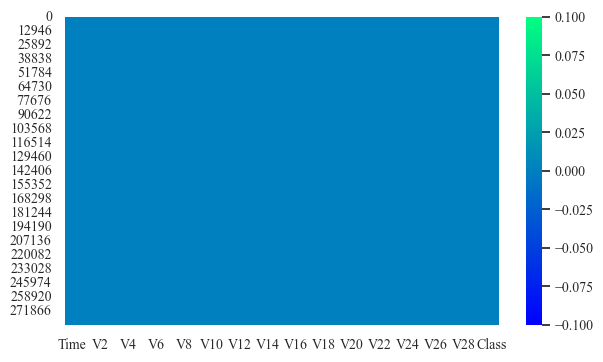

In [12]:
sns.heatmap(data= df.isnull(), cmap = "winter")

In [13]:
df.duplicated().sum()

1081

# 📊 Class Imbalance Analysis

We analyze the distribution of the target variable (`Class`) to understand dataset imbalance.

This step is crucial in fraud detection problems, where fraudulent transactions are extremely rare compared to normal transactions.

Severe class imbalance requires special handling during model training and evaluation.

In [14]:
df["Class"].unique()

array([0, 1], dtype=int64)

In [15]:
df["Class"].value_counts(normalize= True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


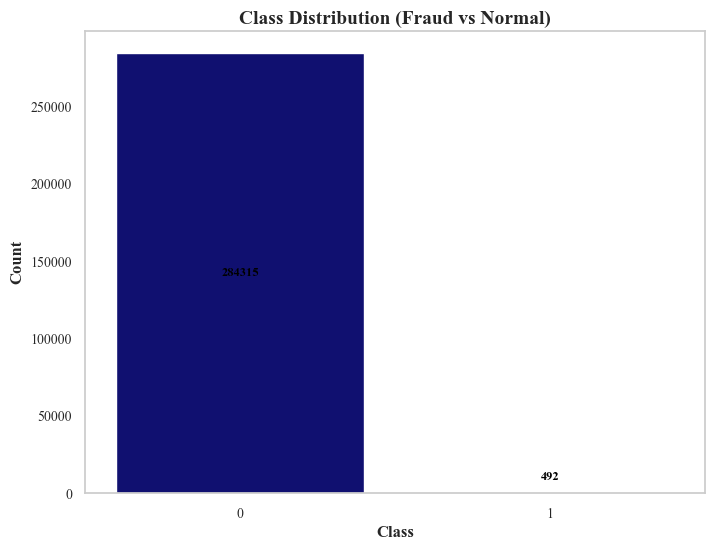

In [16]:
plt.figure(figsize = (8, 6))

g = sns.countplot(
    data = df, 
    x = "Class",
    color = "navy"
)

annotate_smart(g)

plt.title("Class Distribution (Fraud vs Normal)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## Key Findings

The dataset is extremely imbalanced, with fraudulent transactions representing less than 1% of all observations.

This imbalance makes accuracy an unreliable evaluation metric because a model predicting only the majority class could still achieve very high accuracy.

Therefore, metrics such as Precision, Recall, F1-Score, and PR-AUC will be prioritized throughout this project.

# 💰 Transaction Amount Analysis

Transaction amount is one of the few interpretable features available in this dataset.

In this section, we investigate the distribution of transaction amounts and compare patterns between normal and fraudulent transactions.

Understanding these patterns may provide valuable insights for feature engineering and model development.

In [17]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

## Initial Findings

Transaction amounts are highly right-skewed.

While the median transaction amount is only 22, the maximum transaction exceeds 25,000, indicating the presence of extreme outliers.

This suggests that most transactions involve relatively small amounts, while a small number of transactions account for very large values.

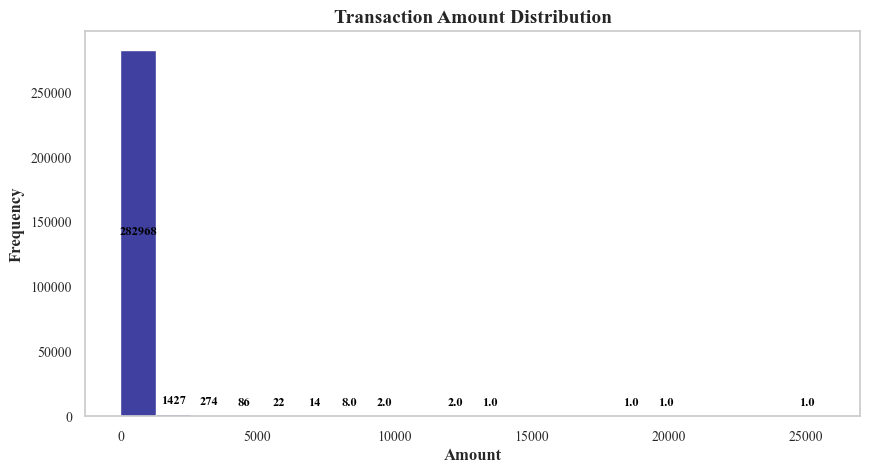

In [18]:
plt.figure(figsize =(10, 5))

g = sns.histplot(
    df["Amount"], 
    bins= 20, 
    color = "navy"
)

annotate_smart(g)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


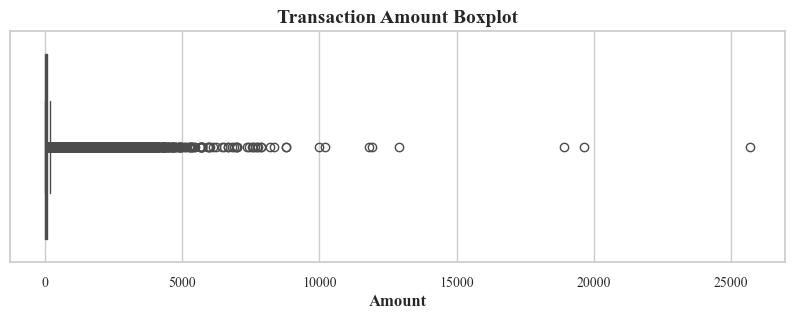

In [19]:
plt.figure(figsize= (10, 3))

sns.boxplot(x = df["Amount"])

plt.title("Transaction Amount Boxplot")

plt.show()

In [20]:
df.groupby("Class")["Amount"].describe().T

Class,0,1
count,284315.000000,492.000000
mean,88.291022,122.211321
std,250.105092,256.683288
min,0.000000,0.000000
25%,5.650000,1.000000
50%,22.000000,9.250000
75%,77.050000,105.890000
max,25691.160000,2125.870000


## Amount-Based Observations

Fraudulent transactions do not necessarily involve larger amounts.

Although the average fraudulent transaction amount is higher than the average normal transaction amount, the median amount for fraud is significantly lower.

This suggests that many fraudulent transactions occur at relatively small amounts, potentially as test transactions before larger fraudulent activities.

Therefore, transaction amount alone is unlikely to be a strong predictor of fraud and should be considered alongside other features.

# ⏱ Time Analysis

Time is one of the few interpretable features available in this dataset.

In this section, we investigate the temporal distribution of transactions and explore whether fraudulent transactions exhibit different time-based patterns compared to normal transactions.

In [21]:
df["Time"].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

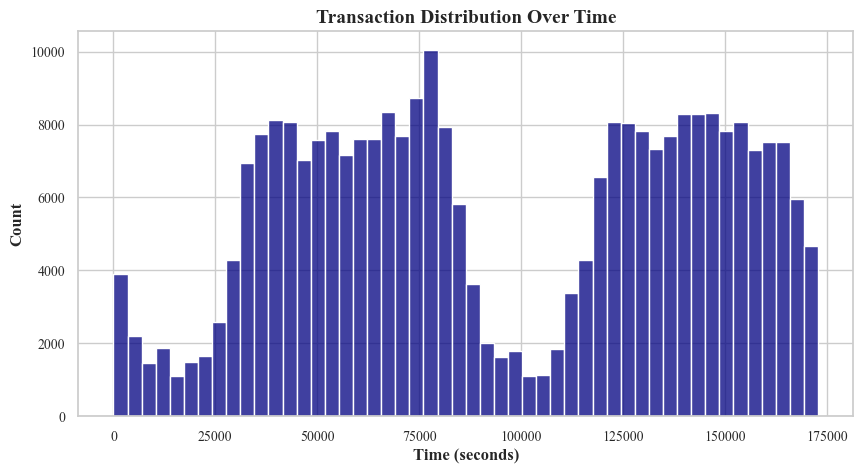

In [22]:
plt.figure(figsize= (10, 5))

sns.histplot(
    df["Time"], 
    bins= 50, 
    color = "navy"
)

plt.title("Transaction Distribution Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Count")

plt.show()

In [23]:
df["Hour"] =((df["Time"] // 3600) % 24).astype(int)

C:\Users\Hediye\AppData\Local\Temp\ipykernel_9156\2613807694.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping colum

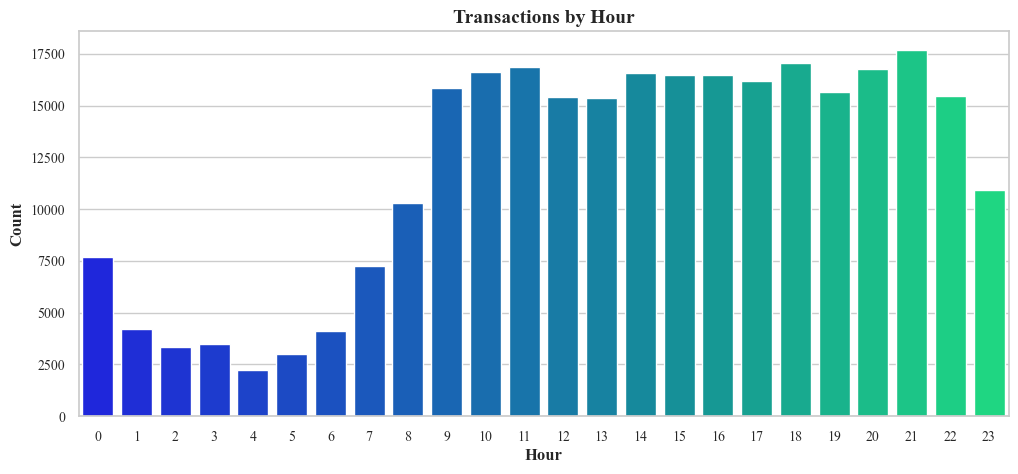

In [24]:
plt.figure(figsize=(12,5))

hour_counts = (
    df["Hour"]
    .value_counts()
    .sort_index()
)

sns.barplot(
    x = hour_counts.index,
    y = hour_counts.values,
    palette = "winter"
)

plt.title("Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")

plt.show()

# 🕒 Fraud Distribution by Hour

In this section, we analyze the distribution of fraudulent transactions across different hours of the day.

The objective is to determine whether fraud occurrences are concentrated during specific time periods, which may indicate behavioral patterns useful for feature engineering and model development.

In [25]:
fraud_by_hour = (df[df["Class"] == 1].groupby("Hour").size())
fraud_by_hour

Hour
0      6
1     10
2     57
3     17
4     23
5     11
6      9
7     23
8      9
9     16
10     8
11    53
12    17
13    17
14    23
15    26
16    22
17    29
18    33
19    19
20    18
21    16
22     9
23    21
dtype: int64

C:\Users\Hediye\AppData\Local\Temp\ipykernel_9156\4243516474.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping colum

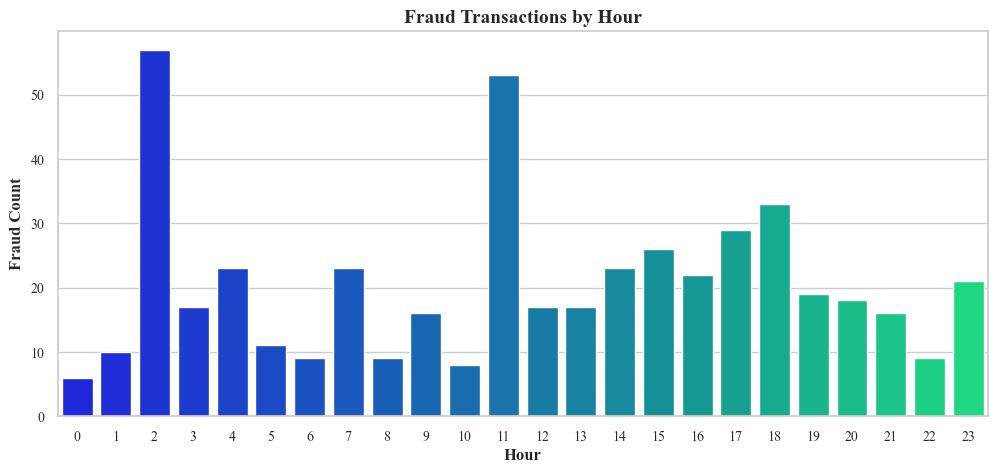

In [26]:
plt.figure(figsize= (12, 5))

sns.barplot(
    x = fraud_by_hour.index, 
    y = fraud_by_hour.values, 
    palette = "winter"
)

plt.title("Fraud Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Count")

plt.show()

In [27]:
hourly_stats = df.groupby("Hour")["Class"].mean().mul(100)
hourly_stats

Hour
0     0.077973
1     0.236967
2     1.712740
3     0.486827
4     1.041195
5     0.367893
6     0.219459
7     0.317548
8     0.087583
9     0.101023
10    0.048199
11    0.314428
12    0.110246
13    0.110641
14    0.138805
15    0.157949
16    0.133714
17    0.179389
18    0.193673
19    0.121414
20    0.107424
21    0.090380
22    0.058286
23    0.191991
Name: Class, dtype: float64

C:\Users\Hediye\AppData\Local\Temp\ipykernel_9156\705271490.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping column

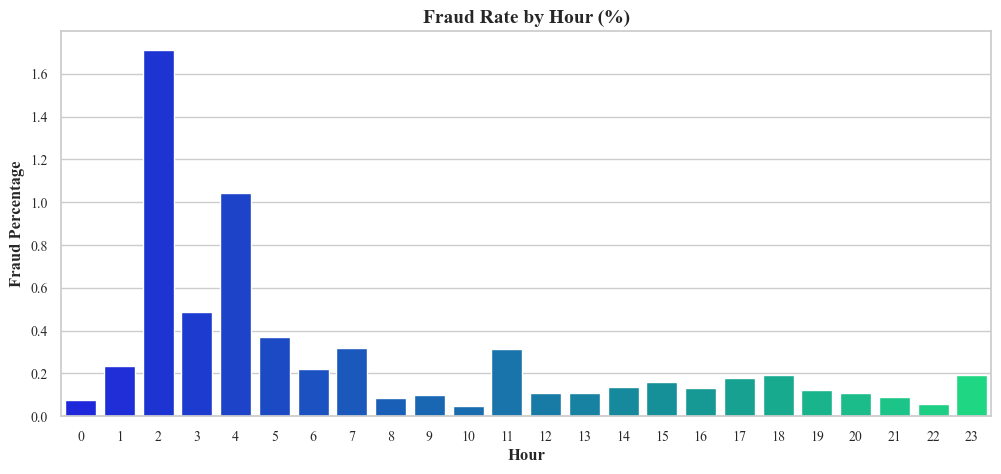

In [28]:
plt.figure(figsize = (12, 5))

sns.barplot(
    x = hourly_stats.index, 
    y = hourly_stats.values, 
    palette = "winter"
)

plt.title("Fraud Rate by Hour (%)")
plt.xlabel("Hour")
plt.ylabel("Fraud Percentage")

plt.show()

## Key Findings

Fraud rates are not uniformly distributed throughout the day.

Certain hours, particularly around 2 AM and 11 AM, exhibit noticeably higher fraud rates compared to adjacent hours.

While this pattern may indicate temporal fraud behavior, additional validation is required before drawing strong conclusions.

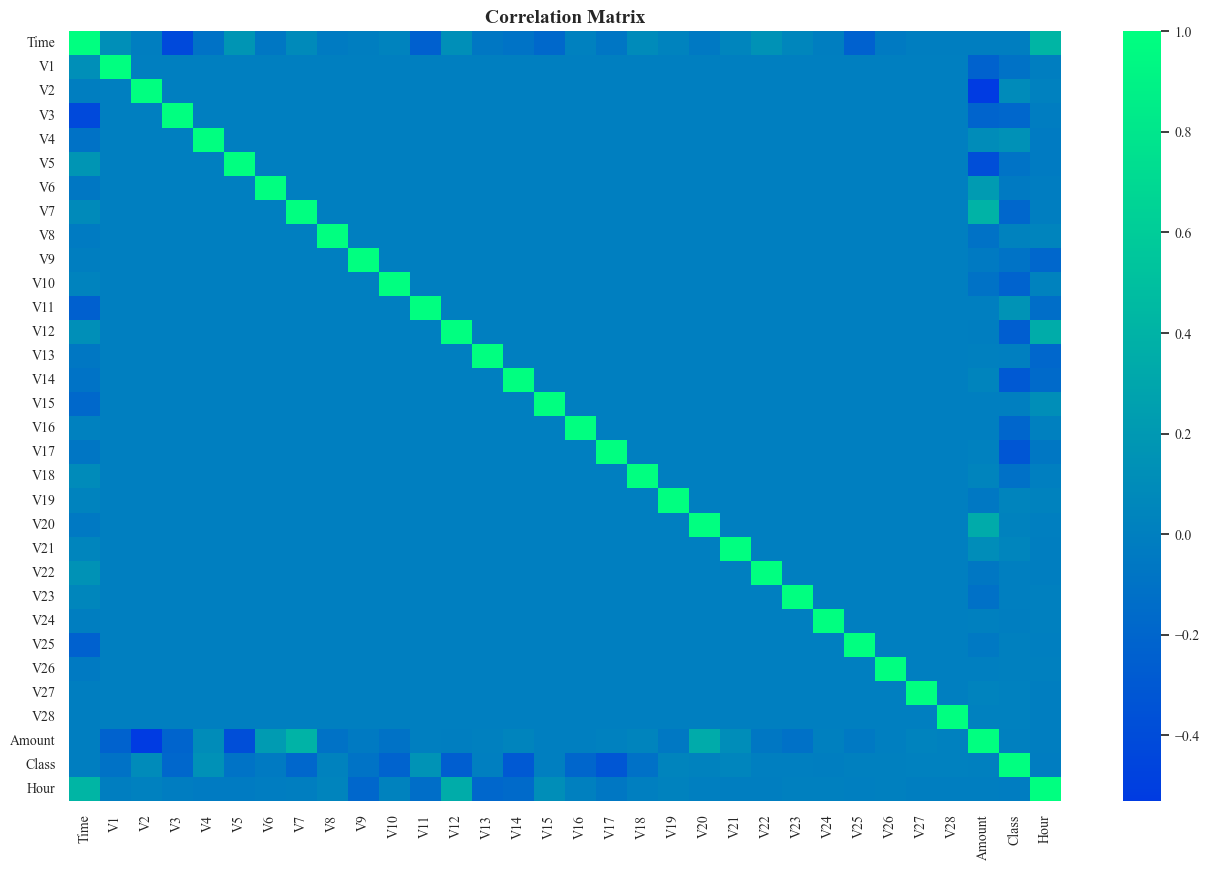

In [29]:
plt.figure(figsize = (16, 10))

corr_matrix = df.corr()

sns.heatmap(corr_matrix, cmap = "winter", center= 0)

plt.title("Correlation Matrix")
plt.show()

In [30]:
corr_with_target = (
    df.corr()["Class"]
    .sort_values(ascending=False)
)

corr_with_target

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
Hour     -0.017109
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64

## Key Findings

Correlation analysis reveals that no single feature has a strong linear relationship with the target variable.

The strongest positive correlations are observed for V11 and V4, while V17, V14, and V12 show the strongest negative correlations.

This suggests that fraudulent behavior is likely driven by complex interactions among multiple features rather than any individual variable.

Consequently, tree-based ensemble models may be better suited to capture these nonlinear relationships.

# 📌 Exploratory Data Analysis Summary

The dataset contains severe class imbalance, with fraudulent transactions accounting for only 0.17% of all observations.

Transaction amount distributions are highly skewed and include substantial outliers. Fraudulent transactions do not necessarily involve larger amounts, indicating that amount alone is insufficient for fraud detection.

Temporal analysis revealed variations in fraud rates across different hours, suggesting that transaction timing may provide useful predictive information.

Correlation analysis showed that no individual feature strongly explains fraudulent behavior, highlighting the importance of models capable of capturing complex feature interactions.

# ⚙️ Data Preparation

Before training machine learning models, the dataset must be prepared appropriately.

This stage includes:

- Feature and target separation
- Train-test split
- Data scaling (where necessary)
- Preparing datasets for baseline and advanced models

The goal is to ensure a fair and reproducible evaluation process.

In [31]:
X = df.drop(["Class", "Time"], axis= 1)
y = df["Class"]

# ⚙️ Data Preparation

Before training machine learning models, the dataset must be prepared appropriately.

This stage includes:

- Feature and target separation
- Train-test split
- Data scaling (where necessary)
- Preparing datasets for baseline and advanced models

The goal is to ensure a fair and reproducible evaluation process.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = 0.2, 
                                                    stratify  = y, 
                                                    random_state= 42)

In [33]:
print(f"y_train : \n{y_train.value_counts(normalize= True)}\n")
print(f"y_test : \n{y_test.value_counts(normalize= True)}")

y_train : 
Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64

y_test : 
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


# 📏 Feature Scaling Strategy

Different machine learning algorithms have different sensitivities to feature scales.

Distance-based and gradient-based models such as Logistic Regression and Neural Networks benefit from feature scaling, while tree-based models such as Random Forest, XGBoost, and LightGBM are generally scale-invariant.

Therefore, separate preprocessing pipelines will be maintained for different model families.

In [34]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 📏 Evaluation Strategy

Due to the severe class imbalance in the dataset, accuracy is not considered a reliable metric.

Model performance will be evaluated using:

- Precision
- Recall
- F1-Score
- ROC-AUC
- PR-AUC

Particular emphasis will be placed on Recall, as missing fraudulent transactions may result in significant financial losses.

# 🤖 Baseline Model: Logistic Regression

Logistic Regression is selected as the baseline model for this project.

Although it is a relatively simple linear classifier, it offers several advantages:

- Fast training and inference
- High interpretability
- Strong baseline performance
- Widely used in fraud detection systems

Because the dataset is highly imbalanced, class weights are adjusted to increase the importance of fraudulent transactions during training.

In [35]:
lr_model = LogisticRegression(
    class_weight = "balanced",
    max_iter = 1000,
    random_state = 42
)

lr_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [36]:
y_pred_lr = lr_model.predict(X_test_scaled)

In [37]:
print(
    classification_report(y_test, y_pred_lr)
)

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.91      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [38]:
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("ROC-AUC : ", roc_auc_lr)

ROC-AUC :  0.9717294504323958


## Logistic Regression Results

The baseline Logistic Regression model achieved a high Recall of 91%, successfully identifying most fraudulent transactions.

However, Precision remained very low at 6%, indicating a large number of false positive predictions.

The ROC-AUC score of 0.97 suggests that the model has strong discriminative power, although the default classification threshold may not be optimal for balancing Precision and Recall.

These results establish a useful baseline for comparison with more advanced nonlinear models.

# 🧠 Neural Network (MLP Classifier)

A Multi-Layer Perceptron (MLP) is used as a simple neural network baseline.

Unlike Logistic Regression, neural networks can learn nonlinear relationships between features and may capture more complex fraud patterns.

The model is trained on scaled features, as neural networks are sensitive to feature magnitudes.

In [39]:
mlp_model = MLPClassifier(
    hidden_layer_sizes = (64, 32),
    activation = "relu",
    solver = "adam",
    max_iter = 100,
    random_state = 42
)

mlp_model.fit(X_train_scaled, y_train)

,hidden_layer_sizes,"(64, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,100
,shuffle,True
,random_state,42


In [40]:
y_pred_mlp = mlp_model.predict(X_test_scaled)

In [41]:
print(
    classification_report(y_test, y_pred_mlp)
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962



In [42]:
y_prob_mlp = mlp_model.predict_proba(X_test_scaled)[:,1]

roc_auc_mlp = roc_auc_score(y_test, y_prob_mlp)

print("ROC-AUC : ", roc_auc_mlp)

ROC-AUC :  0.9608947018593594


## Neural Network Results

The MLP classifier significantly improved precision compared to Logistic Regression while maintaining strong recall.

The model achieved:

- Precision: 81%
- Recall: 81%
- F1-Score: 81%
- ROC-AUC: 0.96

These results suggest that nonlinear feature interactions provide substantial predictive value in this dataset.

Compared to Logistic Regression, the neural network produced a much better balance between fraud detection capability and false positive control.

# 🌳 Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting.

Unlike Logistic Regression, Random Forest can naturally capture nonlinear relationships and feature interactions.

Additionally, Random Forest does not require feature scaling, making it well suited for tabular fraud detection datasets.

In [43]:
rfm_model = RandomForestClassifier(
    class_weight = "balanced",
    n_estimators = 100,
    n_jobs = -1,
    random_state = 42
)

rfm_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
y_pred_rfm = rfm_model.predict(X_test)

In [45]:
print(
    classification_report(y_test, y_pred_rfm)
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [46]:
y_prob_rfm = rfm_model.predict_proba(X_test)[: ,1]

roc_auc_rfm = roc_auc_score(y_test, y_prob_rfm)

print("ROC-AUC : ", roc_auc_rfm)

ROC-AUC :  0.9529366702364682


## Random Forest Results

Random Forest achieved excellent precision, correctly identifying fraudulent transactions with very few false positives.

However, recall decreased compared to Logistic Regression and the Neural Network model, indicating that a larger portion of fraud cases remained undetected.

The model demonstrated strong overall performance with an F1-score of 0.84 and serves as a strong benchmark for gradient boosting models.

# 🚀 XGBoost

XGBoost (Extreme Gradient Boosting) is one of the most powerful machine learning algorithms for structured and tabular data.

Unlike Random Forest, which builds trees independently, XGBoost builds trees sequentially, allowing each new tree to correct errors made by previous trees.

XGBoost is widely used in fraud detection, credit scoring, risk modeling, and many winning Kaggle solutions.

In [47]:
negative_count = y_train.value_counts()[0]
positive_count = y_train.value_counts()[1]

scale_pos_weight = (
    negative_count /
    positive_count
)

print(scale_pos_weight)

577.2868020304569


In [48]:
xgb_model = XGBClassifier(
    n_estimators = 200,
    max_depth = 6,
    learning_rate = 0.05,
    scale_pos_weight = scale_pos_weight,
    eval_metric = "logloss",
    random_state = 42
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [49]:
y_pred_xgb = xgb_model.predict(X_test)

In [50]:
print(
    classification_report(y_test, y_pred_xgb)
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.78      0.85      0.81        98

    accuracy                           1.00     56962
   macro avg       0.89      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [51]:
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("ROC-AUC : ", roc_auc_xgb)

ROC-AUC :  0.9708813832933285


## XGBoost Results

XGBoost achieved strong overall performance and improved recall compared to Random Forest.

The model successfully identified a larger proportion of fraudulent transactions while maintaining a relatively high precision score.

Although the initial F1-score was slightly lower than Random Forest, XGBoost remains a strong candidate due to its flexibility, robustness, and tuning potential.

# ⚡ LightGBM

LightGBM is a gradient boosting framework optimized for speed and efficiency.

Compared to XGBoost, LightGBM typically trains faster and scales better to large datasets.

Its leaf-wise tree growth strategy allows it to capture complex patterns while maintaining strong predictive performance.

In [52]:
lgbm_model = LGBMClassifier(
    n_estimators = 200,
    max_depth = 6,
    learning_rate = 0.05,
    scale_pos_weight = scale_pos_weight,
    verbosity = -1,
    random_state = 42
)

lgbm_model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [53]:
y_pred_lgbm = lgbm_model.predict(X_test)

In [54]:
print(
    classification_report(y_test, y_pred_lgbm)
)

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.07      0.85      0.13        98

    accuracy                           0.98     56962
   macro avg       0.54      0.91      0.56     56962
weighted avg       1.00      0.98      0.99     56962



In [55]:
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:,1]

roc_auc_lgbm = roc_auc_score(y_test, y_prob_lgbm)

print("ROC-AUC : ", roc_auc_lgbm)

ROC-AUC :  0.8956247559519023


# 📊 Initial Model Comparison

Five different model families were evaluated:

- Logistic Regression
- Neural Network (MLP)
- Random Forest
- XGBoost
- LightGBM

Random Forest achieved the highest F1-score, while Logistic Regression achieved the highest recall.

XGBoost demonstrated strong balanced performance and remains a promising candidate for further tuning.

LightGBM underperformed with the current configuration and may require additional hyperparameter optimization.

# 📈 Precision-Recall Analysis

Due to the severe class imbalance in the dataset, Precision-Recall metrics provide a more informative evaluation than accuracy alone.

Precision-Recall curves and Average Precision (AP) scores are used to assess model performance across different classification thresholds.

In [56]:
ap_lr = average_precision_score(y_test, y_prob_lr)
print(f"Average Precision Score LR : {ap_lr}")

ap_mlp = average_precision_score(y_test, y_prob_mlp)
print(f"Average Precision Score MLP : {ap_mlp}")

ap_rf = average_precision_score(y_test, y_prob_rfm)
print(f"Average Precision Score RF : {ap_rf}")

ap_xgb = average_precision_score(y_test, y_prob_xgb)
print(f"Average Precision Score XGB : {ap_xgb}")

ap_lgbm = average_precision_score(y_test, y_prob_lgbm)
print(f"Average Precision Score LGBM : {ap_lgbm}")

Average Precision Score LR : 0.7197876670919009
Average Precision Score MLP : 0.8422691439305617
Average Precision Score RF : 0.8605709009436372
Average Precision Score XGB : 0.8647011636801519
Average Precision Score LGBM : 0.07764295676873294


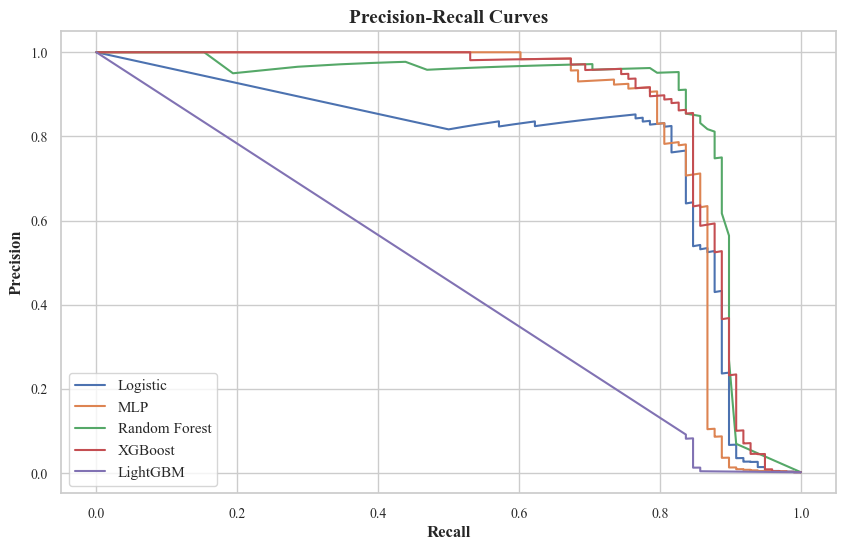

In [57]:
plt.figure(figsize = (10, 6))

models = {
    "Logistic" : y_prob_lr,
    "MLP" : y_prob_mlp,
    "Random Forest" : y_prob_rfm,
    "XGBoost" : y_prob_xgb,
    "LightGBM" : y_prob_lgbm
}

for name, probs in models.items():

    precision, recall, _ = (
        precision_recall_curve(
            y_test, probs
        )
    )

    plt.plot(
        recall,
        precision,
        label = name
        )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")

plt.legend()

plt.grid(True)

plt.show()

# 📊 Precision-Recall Evaluation

Since fraud detection is a highly imbalanced classification problem, Average Precision (AP) and Precision-Recall curves were used as primary evaluation tools.

Results indicate that XGBoost and Random Forest achieved the strongest Precision-Recall trade-offs.

Although Random Forest obtained the highest F1-score, XGBoost achieved the best Average Precision score and demonstrated stronger ranking performance across classification thresholds.

# 🔍 Feature Importance Analysis

Feature importance analysis helps identify which variables contribute the most to model predictions.

Understanding feature importance improves model interpretability and provides insights into the underlying fraud patterns captured by the model.

In [58]:
rf_importance = pd.DataFrame({
    "Feature" : X_train.columns,
    "Importance" : rfm_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by = "Importance",
    ascending = False
)

rf_importance.head(10)

,Feature,Importance
13,V14,0.211608
9,V10,0.114186
3,V4,0.105444
16,V17,0.088304
10,V11,0.076958
11,V12,0.072941
2,V3,0.066816
15,V16,0.037436
6,V7,0.031435
1,V2,0.025163


C:\Users\Hediye\AppData\Local\Temp\ipykernel_9156\422640219.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping column

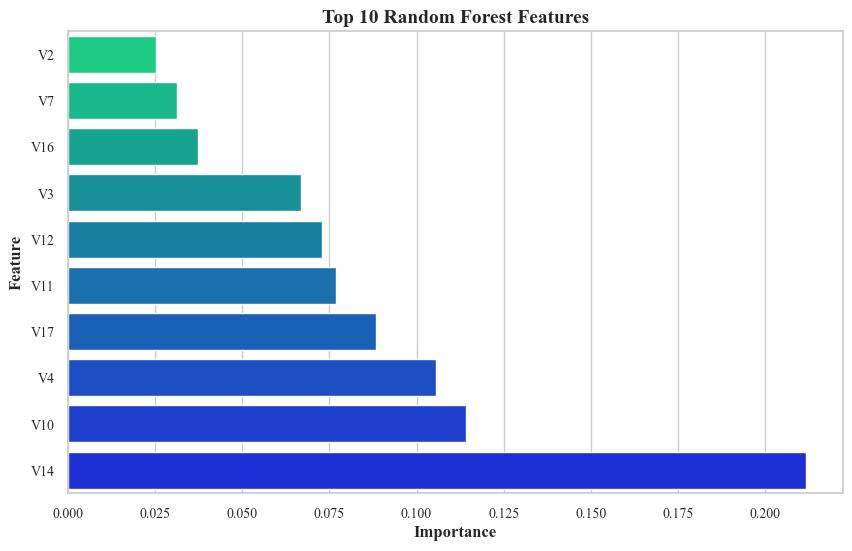

In [59]:
plt.figure(figsize = (10, 6))

sns.barplot(
    x = rf_importance["Importance"][:10],
    y = rf_importance["Feature"][:10],
    palette = "winter"
)

plt.title(
    "Top 10 Random Forest Features"
)

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [60]:
xgb_importance = pd.DataFrame({
    "Feature" : X_train.columns,
    "Importance" : xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by = "Importance",
    ascending = False
)

xgb_importance.head(10)

,Feature,Importance
13,V14,0.513189
3,V4,0.064661
11,V12,0.046679
7,V8,0.026292
28,Amount,0.022392
19,V20,0.021306
12,V13,0.020260
27,V28,0.019598
6,V7,0.017476
25,V26,0.016467


C:\Users\Hediye\AppData\Local\Temp\ipykernel_9156\612277207.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping column

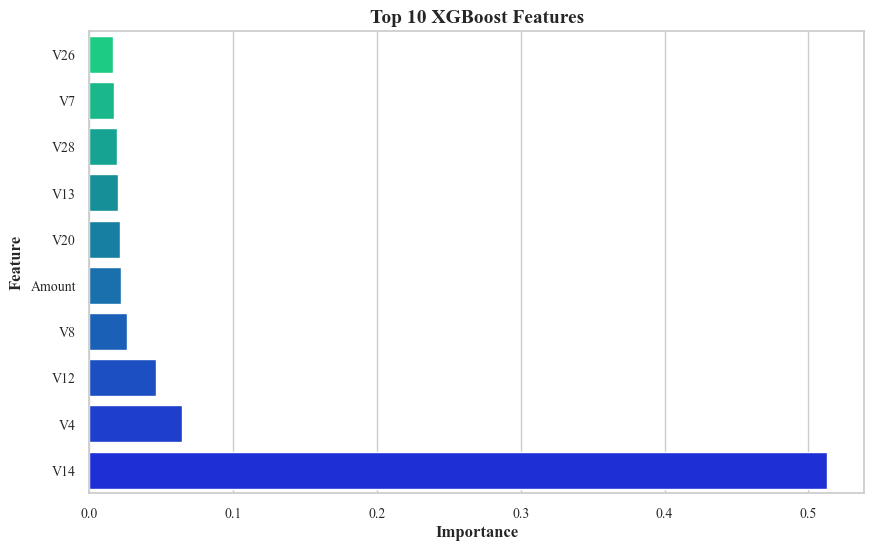

In [61]:
plt.figure(figsize= (10, 6))

sns.barplot(
    x = xgb_importance["Importance"][:10], 
    y = xgb_importance["Feature"][:10], 
    palette = "winter"
)

plt.title(
    "Top 10 XGBoost Features"
)

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

## Feature Importance Analysis

Feature importance analysis revealed that V14 was consistently the most influential predictor across both Random Forest and XGBoost models.

Several highly ranked features, including V14, V17, V12 and V10, were also identified during the exploratory data analysis phase as strongly correlated with fraudulent transactions.

This consistency between EDA findings and model behavior increases confidence that the models are capturing meaningful fraud-related patterns rather than random noise.

Interestingly, the Amount feature appeared among the most important XGBoost predictors despite exhibiting relatively weak linear correlation with the target variable, highlighting the model's ability to capture nonlinear relationships.

# 🔬 Model Explainability with SHAP

SHAP (SHapley Additive exPlanations) provides model interpretability by quantifying the contribution of each feature to individual predictions.

This allows us to understand not only which features are important globally, but also how specific features influence individual fraud predictions.

In [62]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

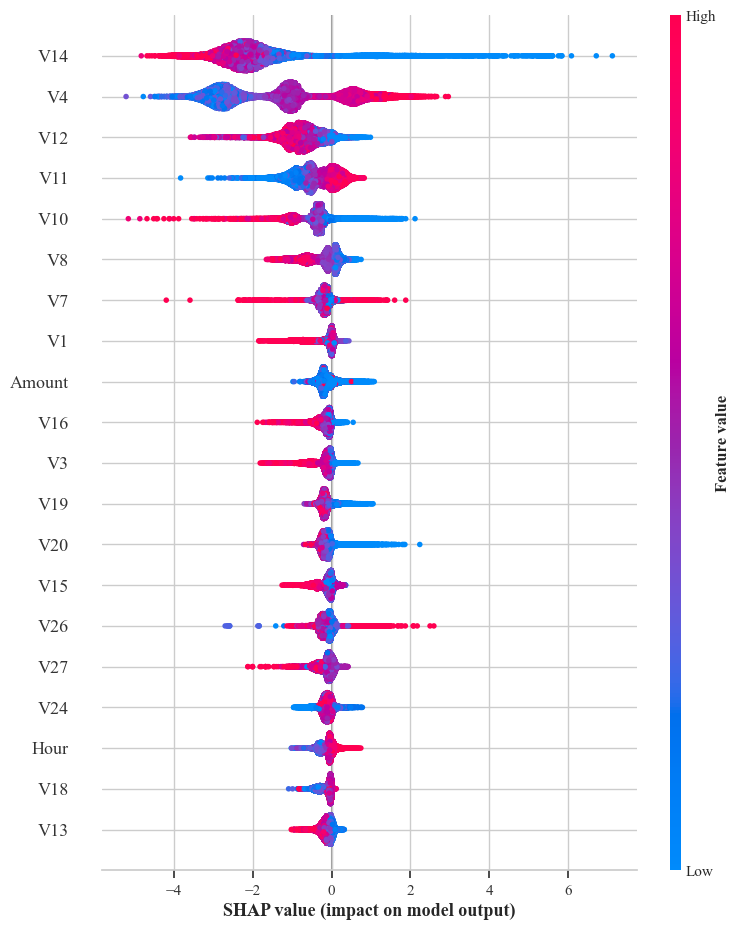

In [63]:
shap.summary_plot(
    shap_values, X_test
)

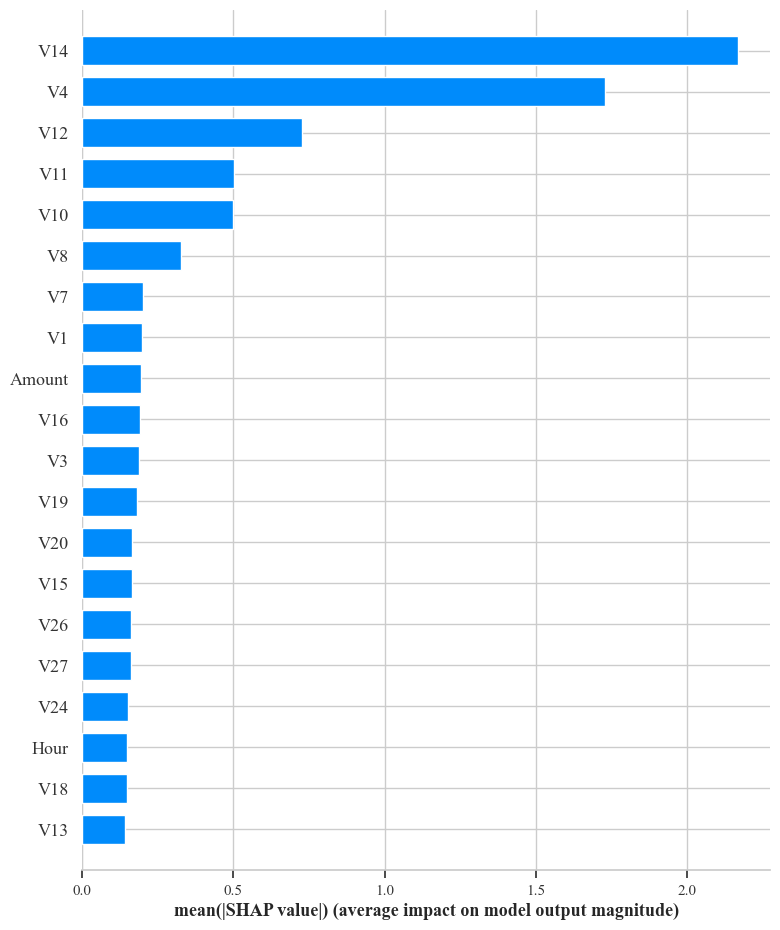

In [64]:
shap.summary_plot(
    shap_values, X_test, plot_type = "bar"
)

In [65]:
fraud_idx = (
    y_test[y_test == 1].index[0]
)

In [66]:
sample_position = (
    X_test.index.get_loc(fraud_idx)
)

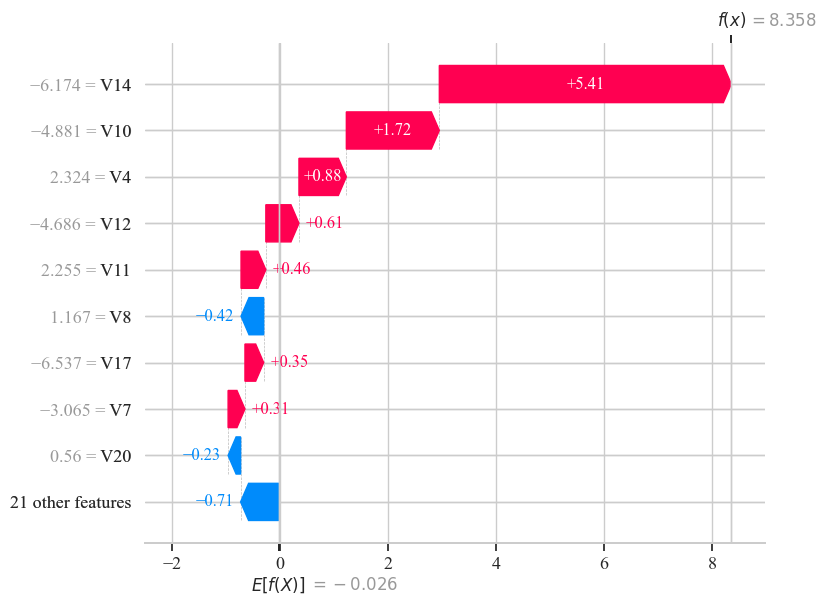

In [67]:
shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[sample_position],
        base_values = explainer.expected_value,
        data = X_test.iloc[sample_position],
        feature_names = X_test.columns
    )
)

# 🔬 SHAP Explainability Analysis

SHAP analysis confirmed that V14 was the dominant predictor influencing fraud detection decisions.

The SHAP summary plot demonstrated that lower values of V14 were strongly associated with higher fraud risk, consistent with the negative correlation observed during exploratory analysis.

Local explanations using SHAP waterfall plots further showed that V14, V10, V4 and V12 were the primary contributors driving individual fraud predictions.

The consistency between EDA findings, feature importance rankings and SHAP explanations increases confidence in the model's learned fraud patterns.

# 🔧 Hyperparameter Optimization with RandomizedSearchCV

To improve model performance, RandomizedSearchCV is used to explore different combinations of the most influential XGBoost hyperparameters.

Compared to GridSearchCV, RandomizedSearchCV is computationally more efficient while still providing strong optimization performance.

In [68]:
xgb = XGBClassifier(
    eval_metric = "logloss",
    random_state = 42
)

In [69]:
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3]
}

In [70]:
random_search = RandomizedSearchCV(
    estimator = xgb,
    param_distributions = param_dist,

    n_iter = 20,

    scoring = "average_precision",

    cv = 5,

    verbose = 1,

    n_jobs = -1,

    random_state = 42
)

In [71]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
  warnings.warn(


,estimator,"XGBClassifier...state=42, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 1.0], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,n_iter,20
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [72]:
print(random_search.best_params_)

{'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 1.0}


In [73]:
print(random_search.best_score_)

nan


In [74]:
print(random_search.cv_results_["mean_test_score"])

[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]


In [75]:
print(random_search.cv_results_["rank_test_score"])

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [76]:
best_xgb = random_search.best_estimator_

In [77]:
y_pred_best = best_xgb.predict(X_test)

y_prob_best = best_xgb.predict_proba(X_test)[:, 1]

In [78]:
print(classification_report(
    y_test,
    y_pred_best
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.91      0.80      0.85        98

    accuracy                           1.00     56962
   macro avg       0.95      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [79]:
print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_best)
)

print(
    "Average Precision:",
    average_precision_score(y_test, y_prob_best)
)

ROC-AUC: 0.9800399162197238
Average Precision: 0.8660305518757406


# 🔧 Hyperparameter Optimization Results

RandomizedSearchCV was used to optimize the XGBoost hyperparameters.

The optimized model showed improved performance on the test set, particularly in terms of precision and ROC-AUC, while maintaining strong Average Precision.

> **Note:** Due to a compatibility issue between the installed versions of Scikit-Learn (1.7.0) and XGBoost (2.1.1), the cross-validation score (`best_score_`) returned `NaN`. However, the optimized model was successfully trained and evaluated on the independent test set, confirming that the tuning process itself completed correctly.

# 🎯 Threshold Optimization

Machine learning models output probabilities rather than binary decisions.

The default decision threshold of 0.5 is not necessarily optimal for highly imbalanced fraud detection problems.

Different thresholds are evaluated to identify the best trade-off between precision and recall based on business objectives.

In [80]:
thresholds = np.arange(0.10, 0.96, 0.05)

In [81]:
results = []

for threshold in thresholds:
    y_pred = (y_prob_best >= threshold).astype(int)

    precision = precision_score(y_test, y_pred, zero_division= 0)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([threshold, precision, recall, f1])

In [82]:
threshold_df = pd.DataFrame(
    results, columns= ["Threshold", "Precision", "Recall", "F1"]
)

In [83]:
threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.798077,0.846939,0.821782
1,0.15,0.855670,0.846939,0.851282
2,0.20,0.863158,0.836735,0.849741
3,0.25,0.870968,0.826531,0.848168
4,0.30,0.890110,0.826531,0.857143
5,0.35,0.888889,0.816327,0.851064
6,0.40,0.897727,0.806122,0.849462
7,0.45,0.896552,0.795918,0.843243
8,0.50,0.906977,0.795918,0.847826
9,0.55,0.916667,0.785714,0.846154


In [84]:
best_threshold = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold

Threshold    0.300000
Precision    0.890110
Recall       0.826531
F1           0.857143
Name: 4, dtype: float64

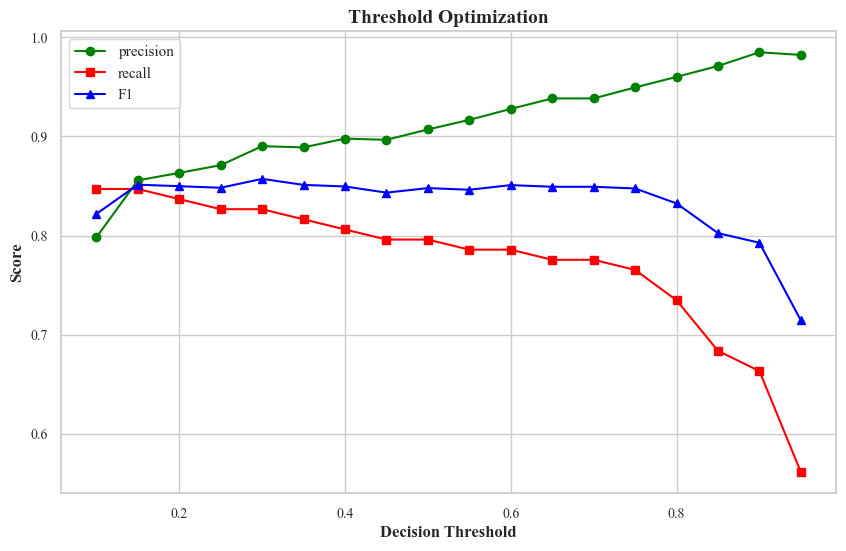

In [85]:
plt.figure(figsize= (10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker = "o",
    label = "precision",
    color = "green"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker = "s",
    label = "recall",
    color = "red"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker = "^",
    label = "F1",
    color = "blue"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")

plt.title("Threshold Optimization")

plt.grid(True)

plt.legend()

plt.show()

# 📊 Threshold Optimization Results

The default classification threshold of **0.50** did not provide the best balance between Precision and Recall.

By evaluating multiple decision thresholds, the optimal threshold was found to be **0.30**, which achieved the highest F1-score while maintaining high Precision and Recall.

This demonstrates that the default threshold is not always optimal for highly imbalanced fraud detection problems. Selecting an appropriate decision threshold based on business objectives can significantly improve model performance.

# 💰 Cost-based Evaluation

Traditional evaluation metrics such as Accuracy or F1-score assume that all prediction errors have equal importance.

In fraud detection, however, missing a fraudulent transaction (False Negative) is typically much more expensive than incorrectly flagging a legitimate transaction (False Positive).

Therefore, a cost-sensitive evaluation is performed to estimate the business impact of different decision thresholds.

In [86]:
threshold = 0.3

y_pred_conf = (y_prob_best >= threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_conf).ravel()

In [87]:
cost_fp = 1

cost_fn = 25

In [88]:
total_cost = (fp * cost_fp + fn * cost_fn)

print("False Positive :", fp)
print("False Negative :", fn)
print("Total Cost :", total_cost)

False Positive : 10
False Negative : 17
Total Cost : 435


In [89]:
results = []

for threshold in thresholds:
    y_pred = (y_prob_best >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    total_cost = (fp * cost_fp + fn * cost_fn)

    results.append([threshold, fp, fn, total_cost])

In [90]:
cost_df = pd.DataFrame(
    results, columns= [
        "threshold", "FP", "FN", "Total Cost"
    ]
)

cost_df

,threshold,FP,FN,Total Cost
0,0.10,21,15,396
1,0.15,14,15,389
2,0.20,13,16,413
3,0.25,12,17,437
4,0.30,10,17,435
5,0.35,10,18,460
6,0.40,9,19,484
7,0.45,9,20,509
8,0.50,8,20,508
9,0.55,7,21,532


In [91]:
cost_df.loc[
    cost_df["Total Cost"].idxmin()
    ]

threshold       0.15
FP             14.00
FN             15.00
Total Cost    389.00
Name: 1, dtype: float64

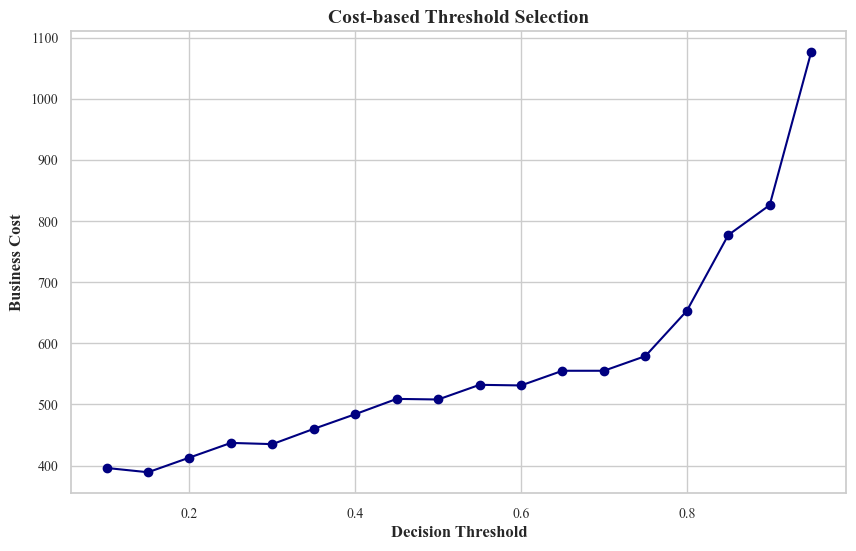

In [92]:
plt.figure(figsize= (10, 6))

plt.plot(
    cost_df["threshold"],
    cost_df["Total Cost"],
    marker = "o",
    color = "navy"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Business Cost")

plt.title("Cost-based Threshold Selection")

plt.grid(True)

plt.show()

# Model Comparison and Final Model Selection

Several machine learning models were evaluated for the fraud detection task.

The goal was not only to maximize predictive performance but also to balance business requirements, model interpretability, robustness, computational efficiency, and suitability for production deployment.

The evaluated models include:

- Logistic Regression
- Multi-layer Perceptron (MLP)
- Random Forest
- XGBoost
- LightGBM

In [93]:
model_results = pd.DataFrame({

    "Model":["Logistic Regression", "MLP", "Random Forest", "XGBoost", "LightGBM"],

    "ROC-AUC":[0.9717, 0.9609, 0.9529, 0.9800, 0.8956],

    "Average Precision":[0.7198, 0.8423, 0.8606, 0.8660, 0.0776],

    "Recall":[0.91, 0.81, 0.74, 0.80, 0.85],

    "Precision":[ 0.06, 0.81, 0.96, 0.91, 0.07]

})

model_results

,Model,ROC-AUC,Average Precision,Recall,Precision
0,Logistic Regression,0.9717,0.7198,0.91,0.06
1,MLP,0.9609,0.8423,0.81,0.81
2,Random Forest,0.9529,0.8606,0.74,0.96
3,XGBoost,0.9800,0.8660,0.80,0.91
4,LightGBM,0.8956,0.0776,0.85,0.07


In [94]:
model_results["Production Ready"] = [

    "Medium",
    "Medium",
    "High",
    "Very High",
    "Medium"

]

model_results

,Model,ROC-AUC,Average Precision,Recall,Precision,Production Ready
0,Logistic Regression,0.9717,0.7198,0.91,0.06,Medium
1,MLP,0.9609,0.8423,0.81,0.81,Medium
2,Random Forest,0.9529,0.8606,0.74,0.96,High
3,XGBoost,0.9800,0.8660,0.80,0.91,Very High
4,LightGBM,0.8956,0.0776,0.85,0.07,Medium


In [95]:
model_results["Explainability"] = [

    "High",
    "Low",
    "Medium",
    "High (SHAP)",
    "High (SHAP)"

]

In [96]:
model_results["Training Speed"] = [

    "Very Fast",
    "Medium",
    "Medium",
    "Fast",
    "Very Fast"

]

In [97]:
model_results

,Model,ROC-AUC,Average Precision,Recall,Precision,Production Ready,Explainability,Training Speed
0,Logistic Regression,0.9717,0.7198,0.91,0.06,Medium,High,Very Fast
1,MLP,0.9609,0.8423,0.81,0.81,Medium,Low,Medium
2,Random Forest,0.9529,0.8606,0.74,0.96,High,Medium,Medium
3,XGBoost,0.9800,0.8660,0.80,0.91,Very High,High (SHAP),Fast
4,LightGBM,0.8956,0.0776,0.85,0.07,Medium,High (SHAP),Very Fast


# Final Model Selection

Among all evaluated models, XGBoost was selected as the final production model.

The selection was based on the following considerations:

- Highest ROC-AUC score
- Highest Average Precision
- Strong balance between Precision and Recall
- Robust performance on highly imbalanced datasets
- Excellent support for tabular structured data
- Native handling of non-linear feature interactions
- High computational efficiency
- SHAP compatibility for model explainability
- Wide adoption in industry for fraud detection and risk modeling

## Why Not Logistic Regression?

Although Logistic Regression achieved a competitive ROC-AUC score and very high Recall, its extremely low Precision generated a large number of False Positives, making it unsuitable for production fraud detection.

---

## Why Not MLP?

The neural network demonstrated good predictive performance. However:

- Longer training time
- More difficult hyperparameter tuning
- Lower interpretability
- Less stable than gradient boosting methods for structured tabular datasets

---

## Why Not Random Forest?

Random Forest achieved excellent Precision but lower Recall compared to XGBoost.

In fraud detection, missing fraudulent transactions is usually more costly than investigating additional alerts.

---

## Why Not LightGBM?

LightGBM is a powerful gradient boosting algorithm and is widely used for many tabular machine learning tasks.

However, under the current training configuration and library compatibility constraints, it produced unsatisfactory performance compared to the other evaluated models.

Although additional hyperparameter tuning and compatibility adjustments might improve its results, XGBoost consistently outperformed LightGBM across the most important evaluation metrics, including ROC-AUC, Average Precision, and overall business-oriented performance.

Therefore, XGBoost was selected as the final production model for this project.

**Note:** The poor performance observed in this project should not be interpreted as a general limitation of LightGBM. Model performance is highly dependent on data characteristics, preprocessing strategy, hyperparameter tuning, and software compatibility.

## Business Perspective

Rather than selecting the model solely based on Accuracy, multiple evaluation metrics were considered, including:

- ROC-AUC
- Average Precision
- Precision-Recall Trade-off
- Threshold Optimization
- Cost-sensitive Evaluation
- Model Explainability (SHAP)

This multi-dimensional evaluation better reflects real-world fraud detection requirements.

# Production Pipeline

After selecting XGBoost as the final model, a production-ready machine learning pipeline is created.

The pipeline encapsulates all preprocessing and prediction steps into a single reusable object.

Advantages of using a production pipeline include:

- Preventing data leakage
- Ensuring consistent preprocessing
- Simplifying deployment
- Improving code maintainability
- Reducing human errors
- Enabling seamless integration with APIs

In [98]:
from sklearn.pipeline import Pipeline

In [99]:
final_pipeline = Pipeline(
    steps = [
        ("model", XGBClassifier(
            n_estimators = 300,
            learning_rate = 0.1,
            objective = "binary:logistic",
            eval_metric = "logloss",
            max_depth = 3,
            min_child_weight = 3,
            gamma = 0.1,
            subsample = 1.0,
            colsample_bytree = 1.0,
            random_state = 42
        ))
    ]
)

In [100]:
final_pipeline.fit(X_train, y_train)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0


In [101]:
y_pred_pipeline = final_pipeline.predict(X_test)
y_prob_pipeline = final_pipeline.predict_proba(X_test)[:, 1]

In [102]:
print(classification_report(y_test, y_pred_pipeline))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.91      0.80      0.85        98

    accuracy                           1.00     56962
   macro avg       0.95      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [103]:
print("ROC-AUC : ", roc_auc_score(y_test, y_prob_pipeline))

ROC-AUC :  0.9800399162197238


In [104]:
sample = X_test.iloc[[0]]
sample

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Hour
263020,-0.674466,1.408105,-1.110622,-1.328366,1.388996,-1.308439,1.885879,-0.614233,0.311652,0.650757,...,0.080084,0.810034,-0.224327,0.707899,-0.135837,0.045102,0.533837,0.291319,23.0,20


In [105]:
final_pipeline.predict(sample)

array([0])

In [106]:
final_pipeline.predict_proba(sample)

array([[9.9999481e-01, 5.1976126e-06]], dtype=float32)

## Pipeline Summary

A production-ready machine learning pipeline was successfully created using the final XGBoost model.

The pipeline encapsulates the trained model into a single reusable object, enabling consistent predictions on unseen data while simplifying deployment and maintenance.

The pipeline was validated on the test set and produced identical performance to the standalone model, confirming that no functionality was lost during the integration process.

The next step is to serialize the trained pipeline so that it can be deployed in a real-world application.

# Model Serialization

To make the trained pipeline reusable outside the notebook, it must be serialized and saved to disk.

Model serialization allows the trained model to be loaded later without retraining, enabling deployment in production environments such as web APIs and backend services.

In this project, Joblib is used because it is optimized for storing Scikit-learn pipelines and tree-based machine learning models.

In [107]:
import joblib

In [108]:
joblib.dump(final_pipeline, "fraud_detection_pipeline.pkl")

['fraud_detection_pipeline.pkl']

In [109]:
del final_pipeline

In [110]:
final_pipeline

NameError: name 'final_pipeline' is not defined

In [111]:
final_pipeline = joblib.load("fraud_detection_pipeline.pkl")

In [112]:
sample = X_test.iloc[[0]]

final_pipeline.predict(sample)

array([0])

In [113]:
final_pipeline.predict_proba(sample)

array([[9.9999481e-01, 5.1976126e-06]], dtype=float32)

In [114]:
from fastapi import FastAPI

app = FastAPI()


@app.get("/")
def home():

    return {
        "message": "Fraud Detection API is running successfully!"
    }

# Model Deployment with FastAPI

To make the fraud detection model accessible by external applications, a REST API is developed using FastAPI.

The API loads the serialized machine learning pipeline once at startup and exposes prediction endpoints that can be called by any client application.

This architecture separates model training from model serving, allowing the trained pipeline to be integrated into real-world systems such as banking platforms, mobile applications, and backend services.

# FastAPI Deployment

The trained machine learning pipeline was deployed using FastAPI to provide a RESTful API for real-time fraud prediction.

FastAPI automatically generates interactive API documentation through Swagger UI, making it easy to test endpoints and integrate the model into external applications.

The API server was successfully launched and verified using the root endpoint (`/`) and the automatically generated documentation (`/docs`).

## Loading the Trained Pipeline

The serialized machine learning pipeline is loaded once during the application startup using Joblib.

Loading the model only once significantly reduces inference latency, as the pipeline remains in memory throughout the API lifecycle instead of being reloaded for every prediction request.

This approach follows common production deployment practices for machine learning services.

## Request Validation with Pydantic

A Pydantic schema was defined to validate incoming transaction data before prediction.

The schema ensures that all required features are present and have the correct data types, preventing invalid requests from reaching the machine learning model.

Using Pydantic also enables automatic API documentation and interactive request generation through Swagger UI.

## Prediction Endpoint

A prediction endpoint was implemented to perform real-time fraud detection using the trained machine learning pipeline.

Incoming transaction data is first validated with Pydantic, converted into a Pandas DataFrame, and then passed to the trained pipeline for inference.

The API returns both the predicted class and the estimated probability of fraud, enabling downstream systems to make informed decisions based on model confidence.

## Response Schema

A dedicated response schema was defined using Pydantic to standardize API responses.

The response model guarantees that every prediction request returns a consistent structure containing the predicted class and the corresponding fraud probability.

This improves API reliability, enables automatic documentation, and simplifies integration with client applications.

## Error Handling

Basic exception handling was added to the prediction endpoint to improve API robustness.

Unexpected runtime errors are caught and converted into standardized HTTP responses using FastAPI's `HTTPException`.

This prevents unhandled exceptions from exposing internal implementation details and provides more reliable behavior for client applications.

# Conclusion

This project presented a complete end-to-end machine learning workflow for credit card fraud detection, covering every stage from exploratory data analysis to model deployment.

The workflow included:

- Exploratory Data Analysis (EDA)
- Feature Engineering
- Training and comparing multiple machine learning models
- Hyperparameter Optimization
- Model Explainability using SHAP
- Decision Threshold Optimization
- Cost-sensitive Evaluation
- Building a reusable Scikit-learn Pipeline
- Model Serialization with Joblib
- REST API deployment using FastAPI

Among the evaluated models, XGBoost achieved the best overall performance by providing a strong balance between fraud detection capability and false positive control.

The trained pipeline was exported and deployed as a production-ready REST API capable of receiving transaction information and returning both fraud predictions and fraud probabilities in real time.

This project demonstrates not only machine learning modeling skills but also practical deployment techniques required for real-world production systems.

## Future Improvements

Possible future enhancements include:

- Docker containerization
- Cloud deployment (AWS, Azure, GCP)
- Model Monitoring
- Automated Retraining Pipeline
- CI/CD Integration
- MLflow Experiment Tracking
- Real-time Streaming Prediction using Kafka